<a href="https://colab.research.google.com/github/Allwin755/Flashcard/blob/main/Accidentsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Accident Severity Prediction in India**
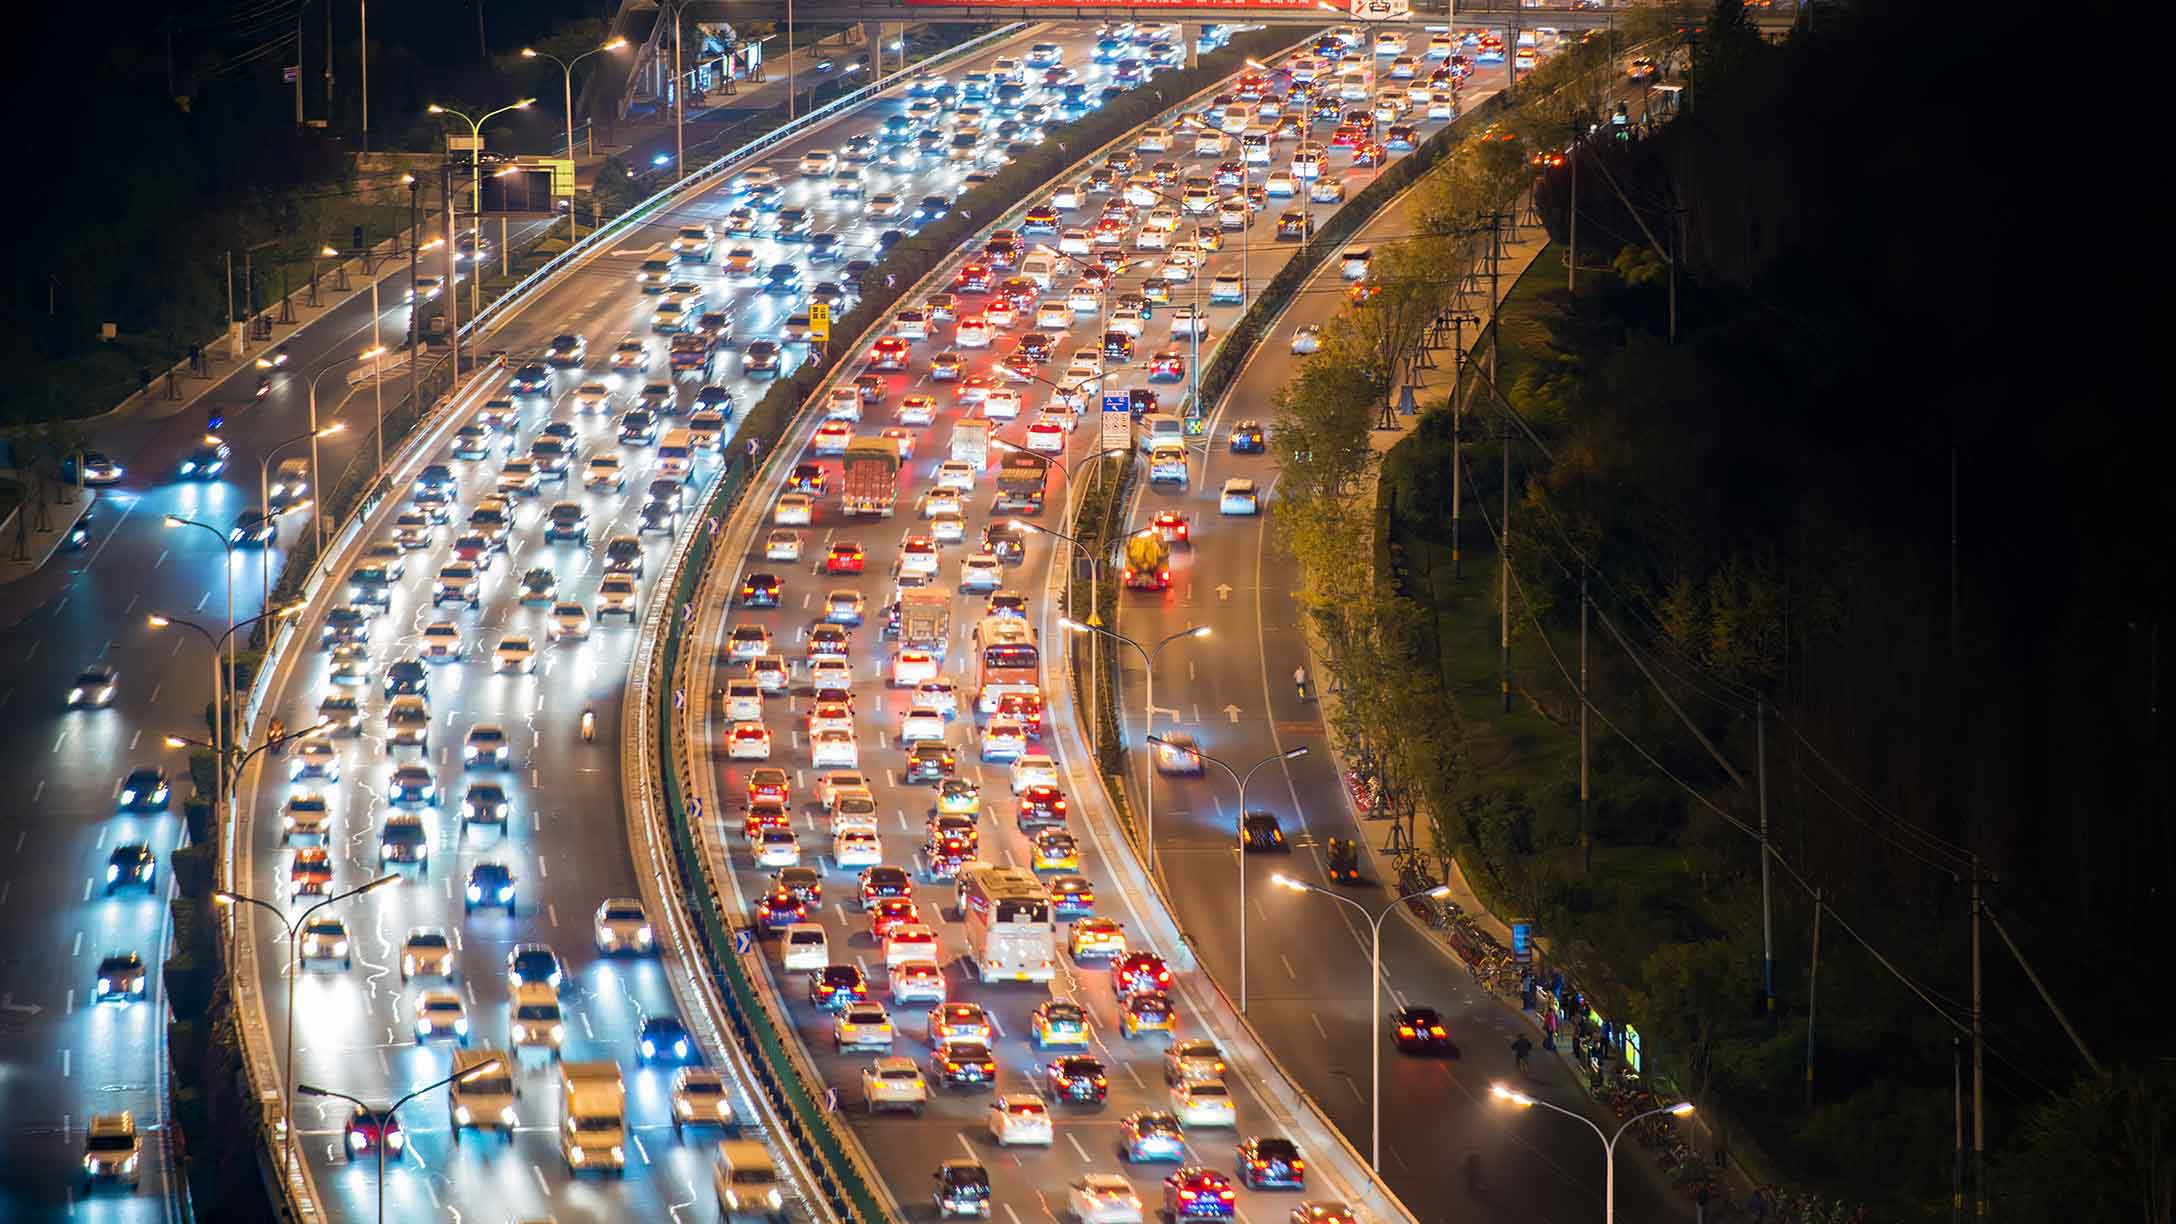

**Introduction**

In India, road accidents result in thousands of injuries and fatalities each year, with many cases caused by factors such as road conditions, weather, time of day, and driver behavior. This project will leverage historical accident data and analyze various features such as traffic density, vehicle type, age and experience of drivers, and location-specific characteristics to uncover significant patterns associated with accident severity. By integrating machine learning techniques, the model aims to provide insights into high-risk zones and predict potential accident outcomes based on prevailing conditions. The ultimate objective is to aid authorities in prioritizing infrastructure improvements, deploying timely safety interventions, and optimizing resource allocation for emergency response. This data-driven approach will support policymakers in developing targeted strategies to reduce accident rates and improve overall road safety for all citizens.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Road.csv', encoding='utf-8')

**Understaing the Data**

In [ ]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [ ]:
df.isna().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [ ]:
for i in df:
    if df[i].dtype=='object':
        print(df[i].value_counts())
        print('-----')

Time
15:30:00    120
17:10:00    110
18:30:00    103
11:30:00     99
17:00:00     98
           ... 
19:04:00      1
20:36:00      1
22:54:00      1
21:03:00      1
2:47:00       1
Name: count, Length: 1074, dtype: int64
-----
Day_of_week
Friday       2041
Thursday     1851
Wednesday    1840
Tuesday      1770
Monday       1681
Saturday     1666
Sunday       1467
Name: count, dtype: int64
-----
Age_band_of_driver
18-30       4271
31-50       4087
Over 51     1585
Unknown     1548
Under 18     825
Name: count, dtype: int64
-----
Sex_of_driver
Male       11437
Female       701
Unknown      178
Name: count, dtype: int64
-----
Educational_level
Junior high school    7619
Elementary school     2163
High school           1110
Above high school      362
Writing & reading      176
Unknown                100
Illiterate              45
Name: count, dtype: int64
-----
Vehicle_driver_relation
Employee    9627
Owner       1973
Other        123
Unknown       14
Name: count, dtype: int64
-----
Driving

**Feature Extraction**

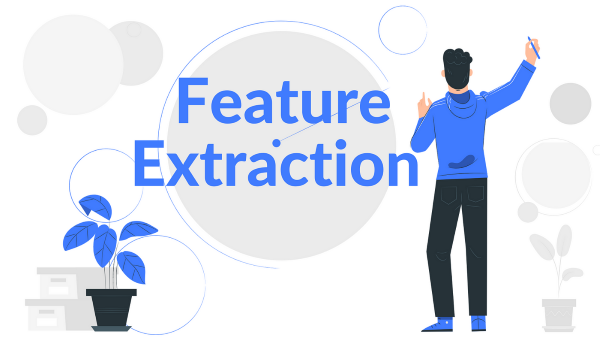

In the process of feature extraction, extracting the hour from a "time of occurrence" column can be a valuable step, especially when the hour is a relevant feature in predicting or understanding the data.

In [ ]:
df['Hour'] = df['Time'].str.split(':').str[0:1]

In [ ]:
df['Hour']=df['Hour'].apply(lambda x: x[0]).astype(int)

In [ ]:
df['Hour'].dtype

dtype('int64')

# **EDA**
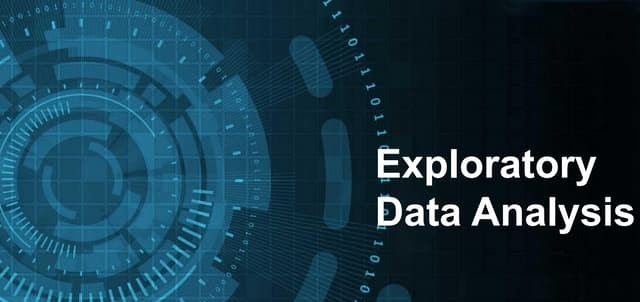






**Data Cleaning**

In data cleaning, we make adjustments to improve data consistency and
quality for analysis. These adjustments include:

* Removing White Spaces: Leading and trailing white spaces can make two similar entries appear different. Removing them ensures consistency across the dataset.

* Standardizing Categories: Sometimes, the same category is represented in slightly different ways. We standardize by substituting these variations with a single consistent label.

* Combining Similar Categories: Occasionally, categories with similar meanings are split across different labels. For instance, "RuralvillageareasOfficeareas" and "Ruralvillageareas" may refer to the same meaning. We can unify these categories to reduce redundancy and provide clearer insights.

* Correcting Spelling Errors: Spelling mistakes can create multiple entries for the same value. Correcting these mistakes helps in grouping data accurately




In [ ]:
df['Area_accident_occured'] = df['Area_accident_occured'].str.replace(r'\s+', '', regex=True)

In [ ]:
df['Area_accident_occured'].replace('RuralvillageareasOfficeareas','Ruralvillageareas',inplace=True)

<ipython-input-711-b5b33e6e0a79>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Area_accident_occured'].replace('RuralvillageareasOfficeareas','Ruralvillageareas',inplace=True)


In [ ]:
df['Light_conditions'].replace('Darkness - no lighting','Darkness - lights unlit',inplace=True)

<ipython-input-712-5e2557e8575d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Light_conditions'].replace('Darkness - no lighting','Darkness - lights unlit',inplace=True)


In [ ]:
df['Area_accident_occured'].value_counts()

,count
Area_accident_occured,
Other,3819
Officeareas,3451
Residentialareas,2060
Churchareas,1060
Industrialareas,456
Schoolareas,415
Recreationalareas,328
Outsideruralareas,218
Hospitalareas,121


In [ ]:
df['Day_of_week'].replace(['Friday','Thursday','Wednesday','Tuesday','Monday'],'WeekDays',inplace=True)
df['Day_of_week'].replace(['Saturday','Sunday'],'Weekend',inplace=True)

<ipython-input-714-c5c74a12a7c0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Day_of_week'].replace(['Friday','Thursday','Wednesday','Tuesday','Monday'],'WeekDays',inplace=True)


In [ ]:
df['Type_of_vehicle'].replace(['Lorry (41?100Q)','Public (12 seats)','Lorry (11?40Q)','Public (13?45 seats)','Public (> 45 seats)','Long lorry'],['Lorry','Public','Lorry','Public','Public','Lorry'],inplace=True)

<ipython-input-715-4ddad986bc8e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type_of_vehicle'].replace(['Lorry (41?100Q)','Public (12 seats)','Lorry (11?40Q)','Public (13?45 seats)','Public (> 45 seats)','Long lorry'],['Lorry','Public','Lorry','Public','Public','Lorry'],inplace=True)


In [ ]:
df['Accident_severity']=df['Accident_severity'].replace(['Fatal injury','Serious Injury','Slight Injury'],[2,1,0])

<ipython-input-716-4afdb3b7e702>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Accident_severity']=df['Accident_severity'].replace(['Fatal injury','Serious Injury','Slight Injury'],[2,1,0])


In [ ]:
df['Road_allignment']=df['Road_allignment'].replace('Tangent road with mountainous terrain and','Tangent road with mountainous terrain')

In [ ]:
df['Age_band_of_casualty']=df['Age_band_of_casualty'].replace('5','<5')

In [ ]:
df['Age_band_of_casualty']=df['Age_band_of_casualty'].replace('NormalNormal','Normal')

In [ ]:
df['Fitness_of_casuality']=df['Fitness_of_casuality'].replace('na',0)

In [ ]:
df['Casualty_severity']=df['Casualty_severity'].replace('na',0)

**Data Visualisation**

In this analysis, we created visualizations to understand data distribution and the influence of various features on the outcome. By specifically comparing feature distributions across different outcomes, we gained clearer insights into the relationships between features and the target variable.

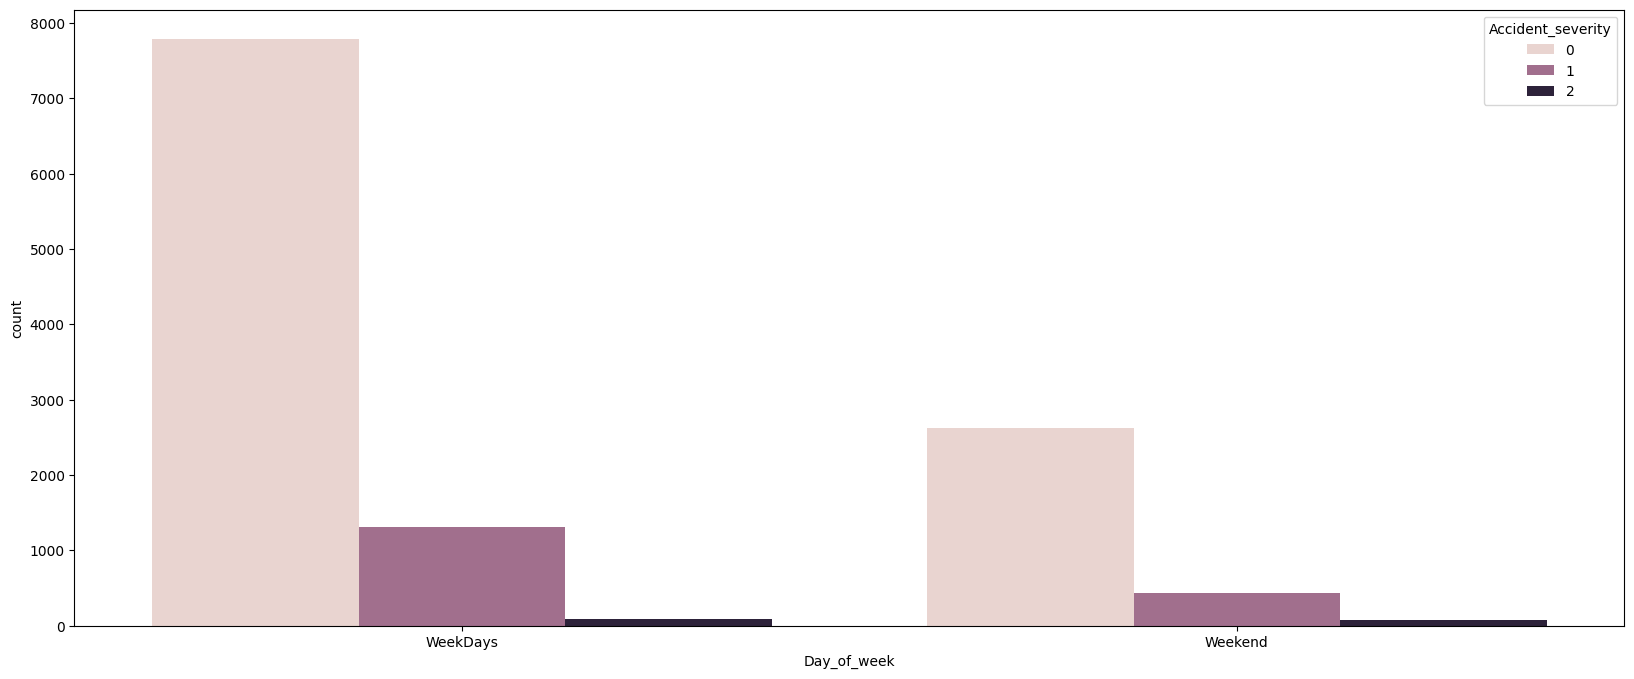

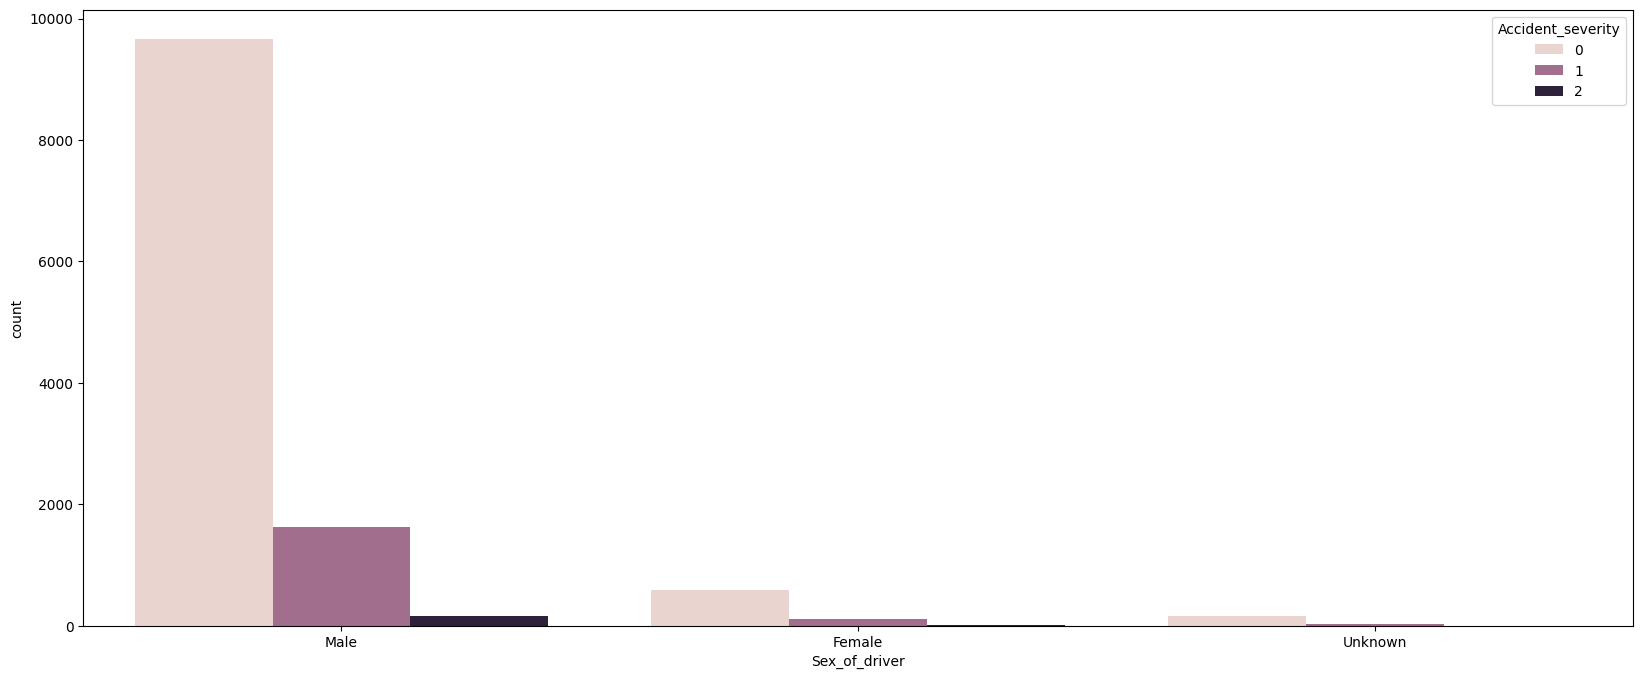

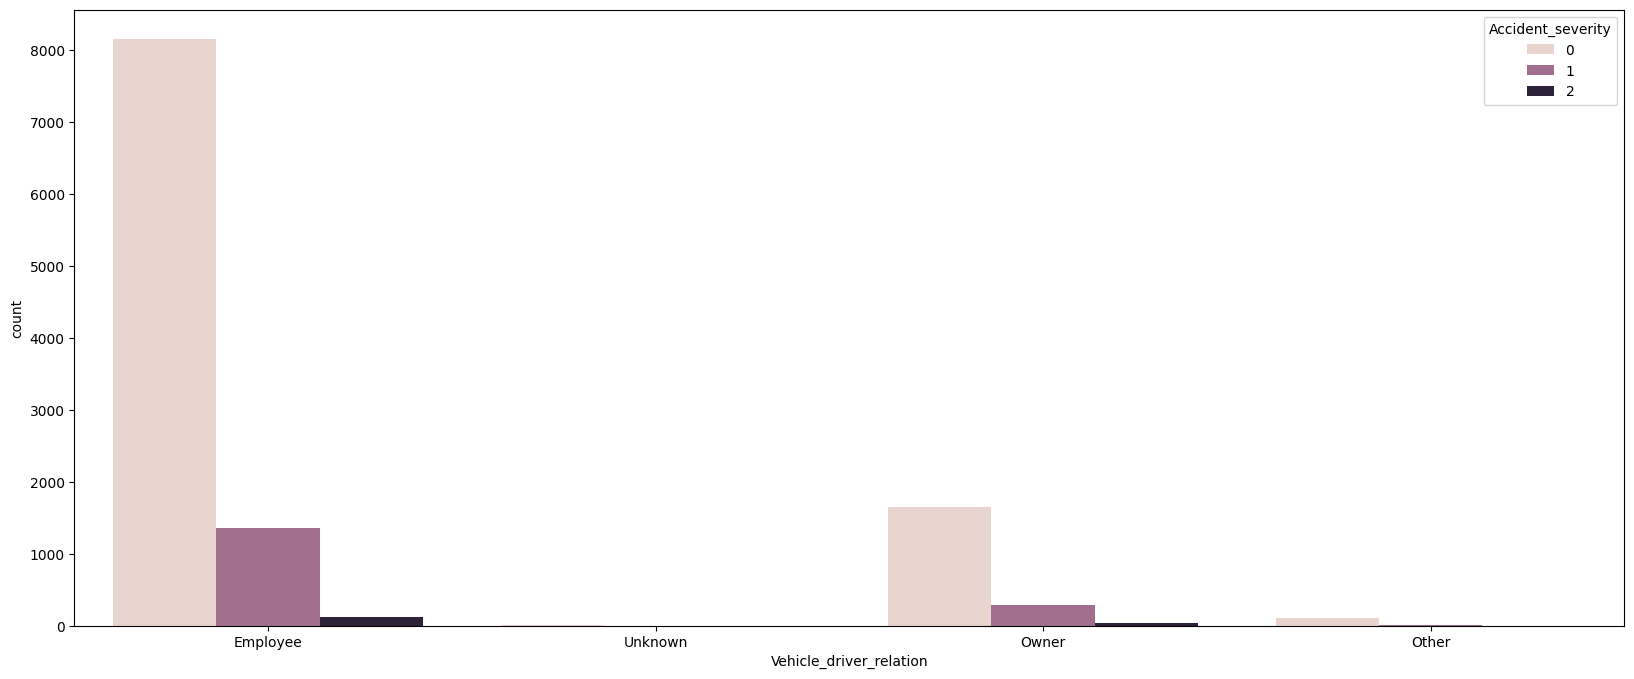

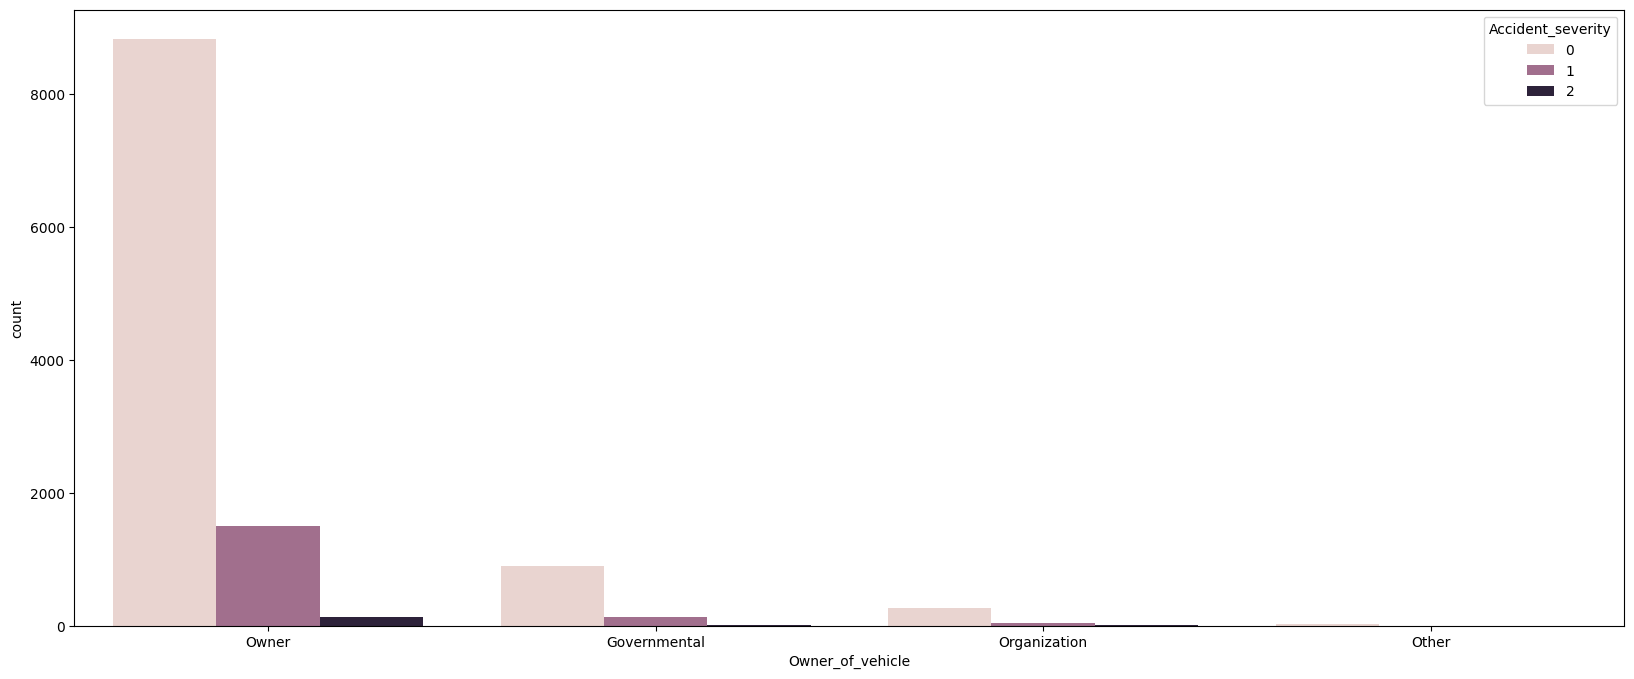

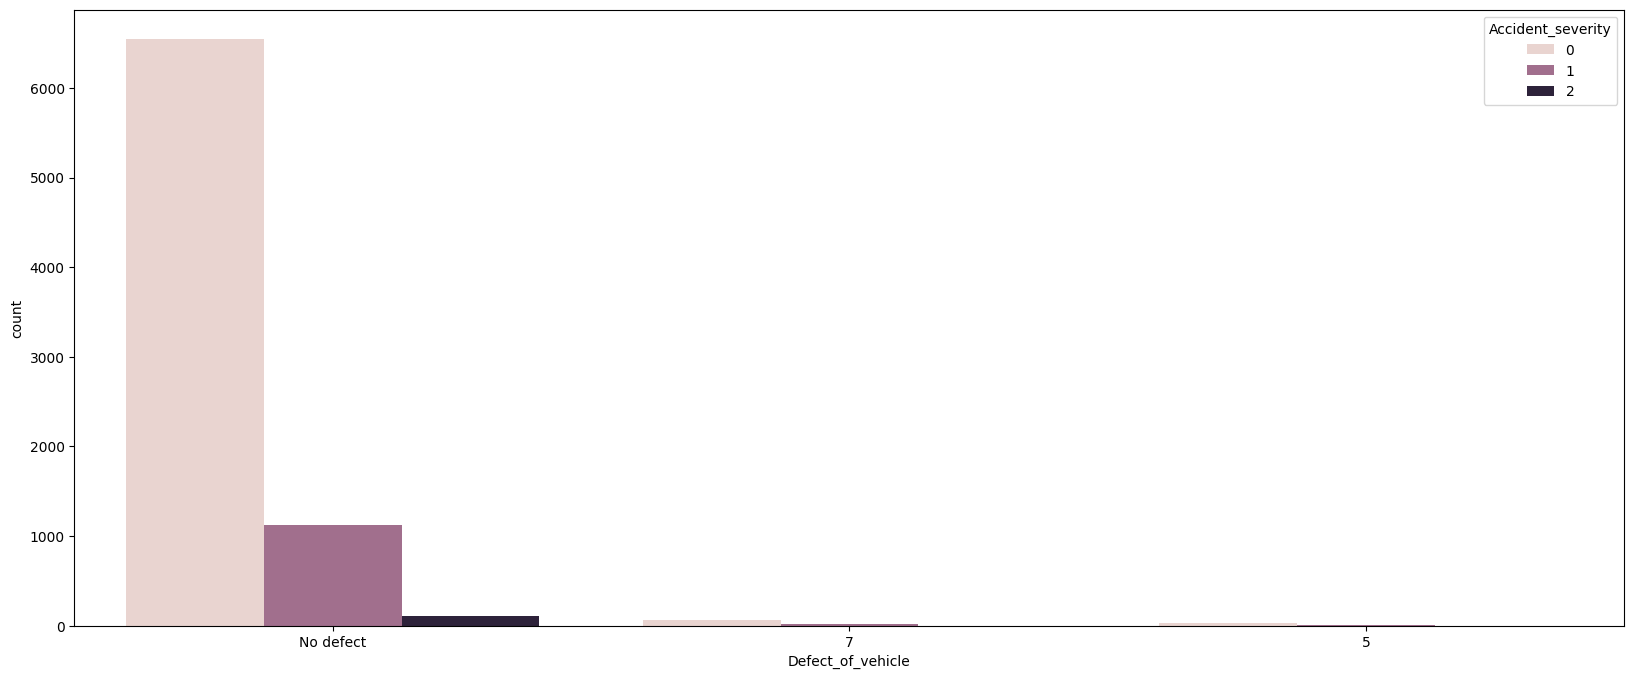

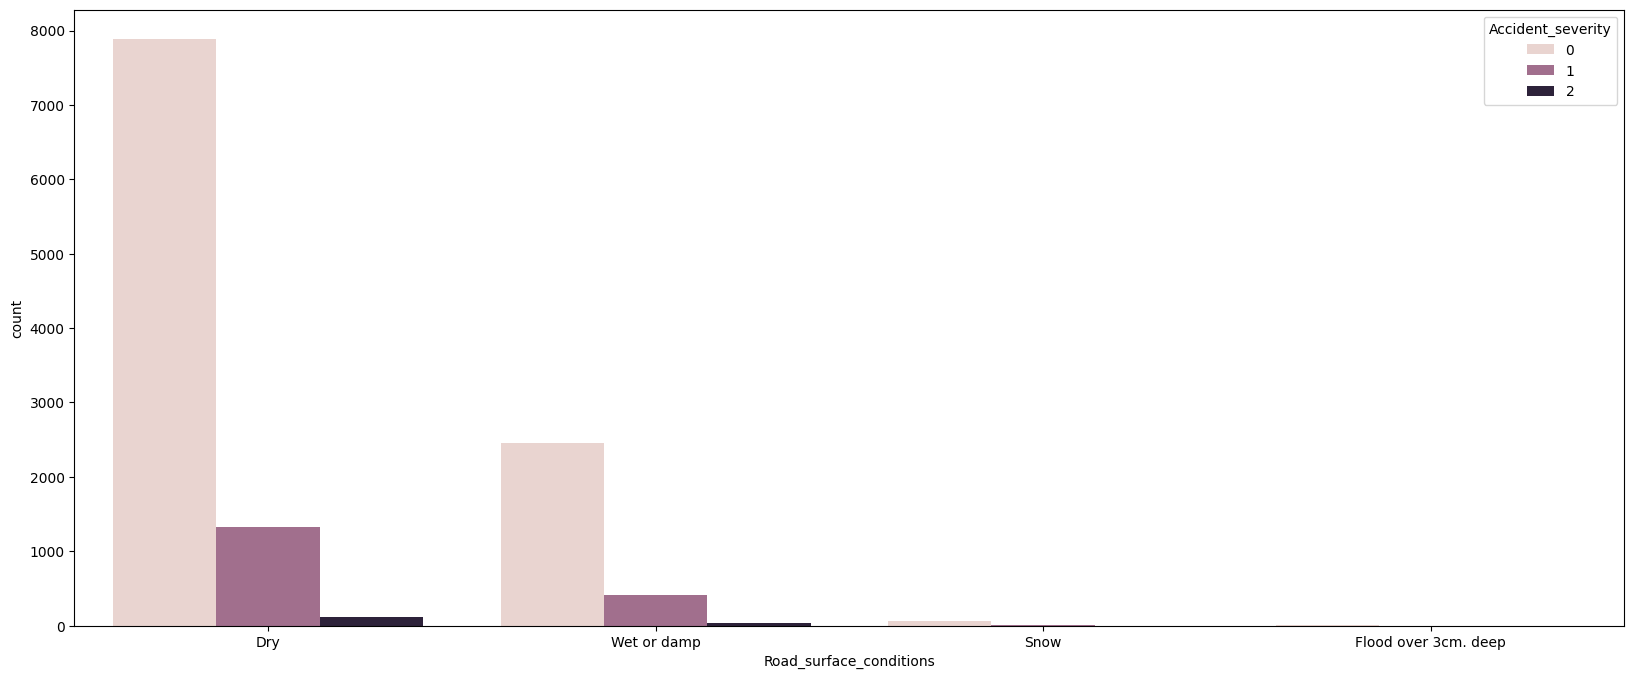

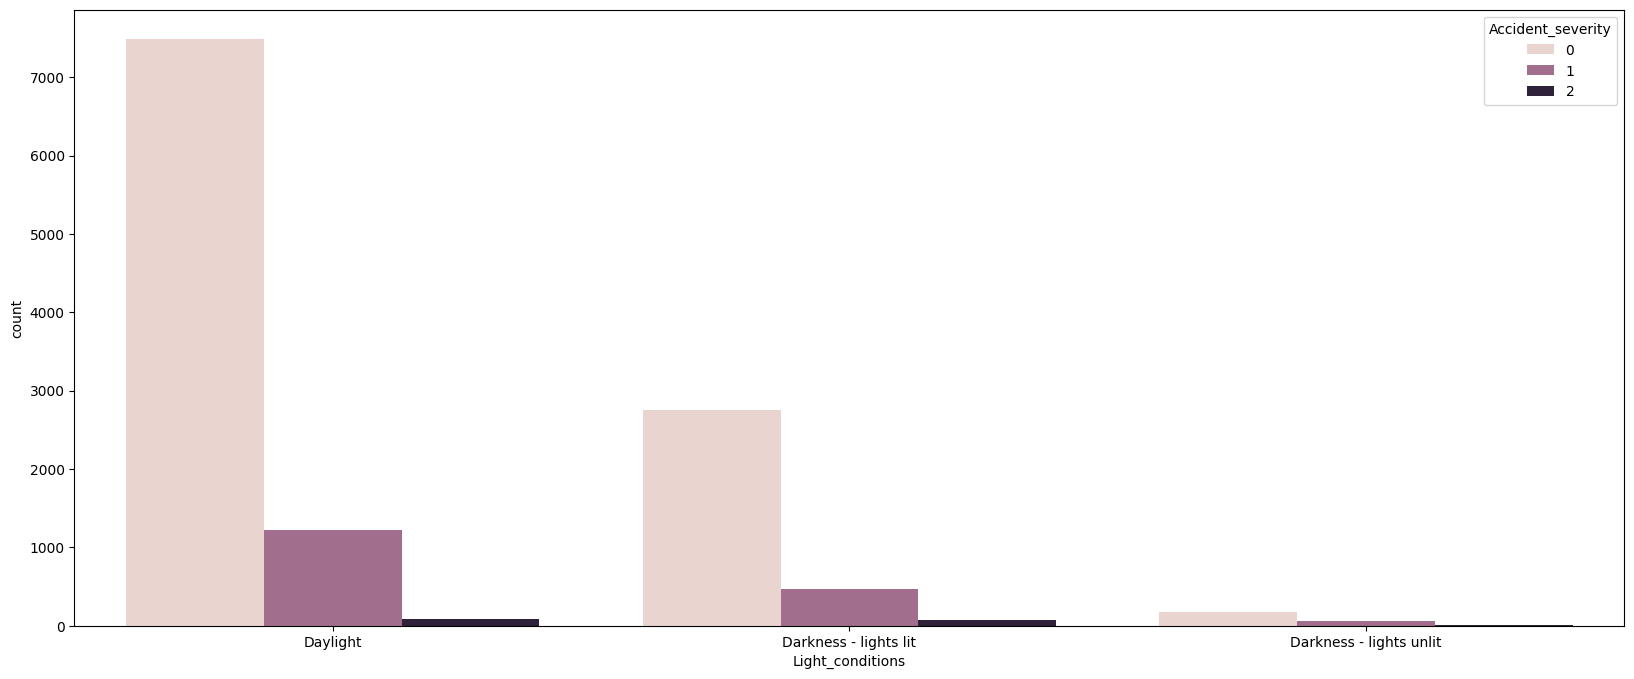

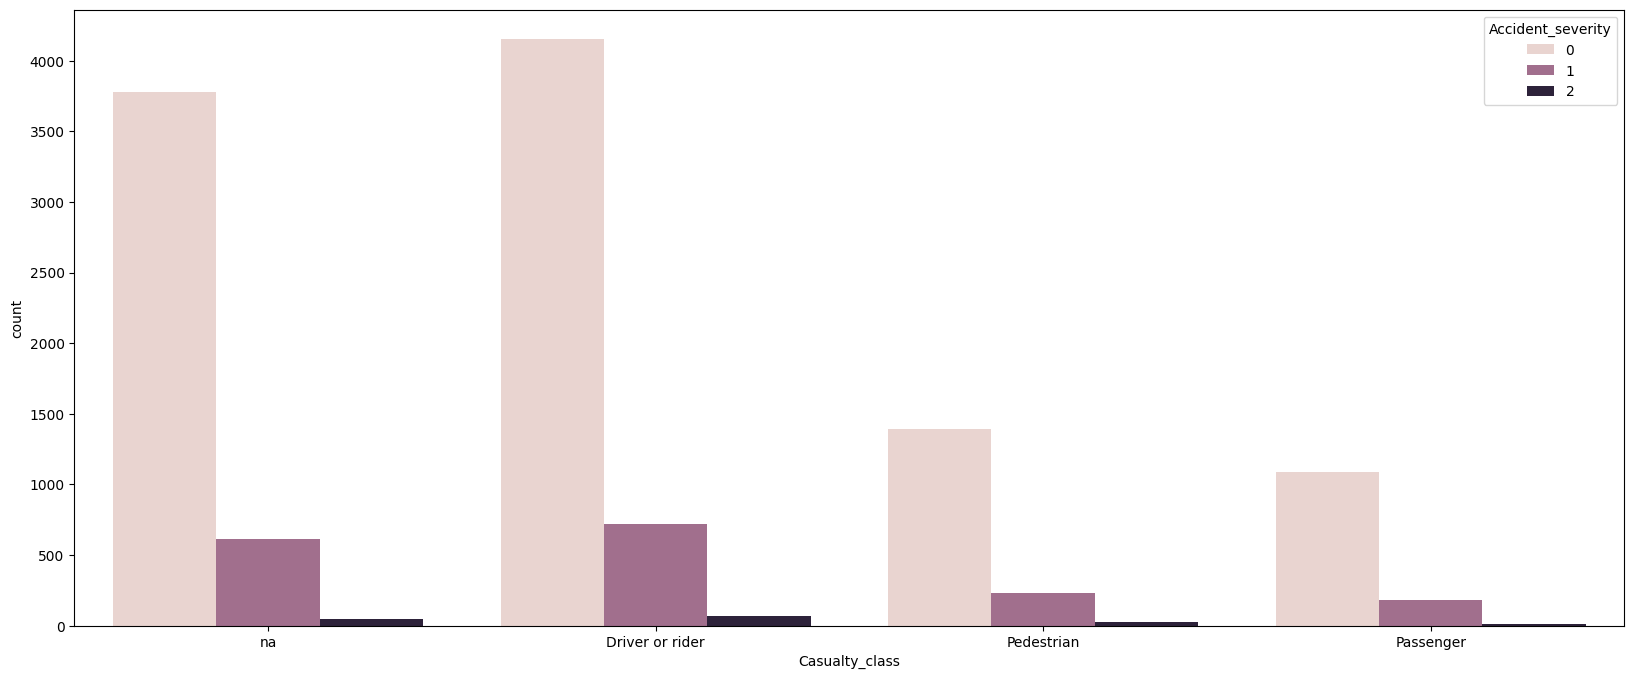

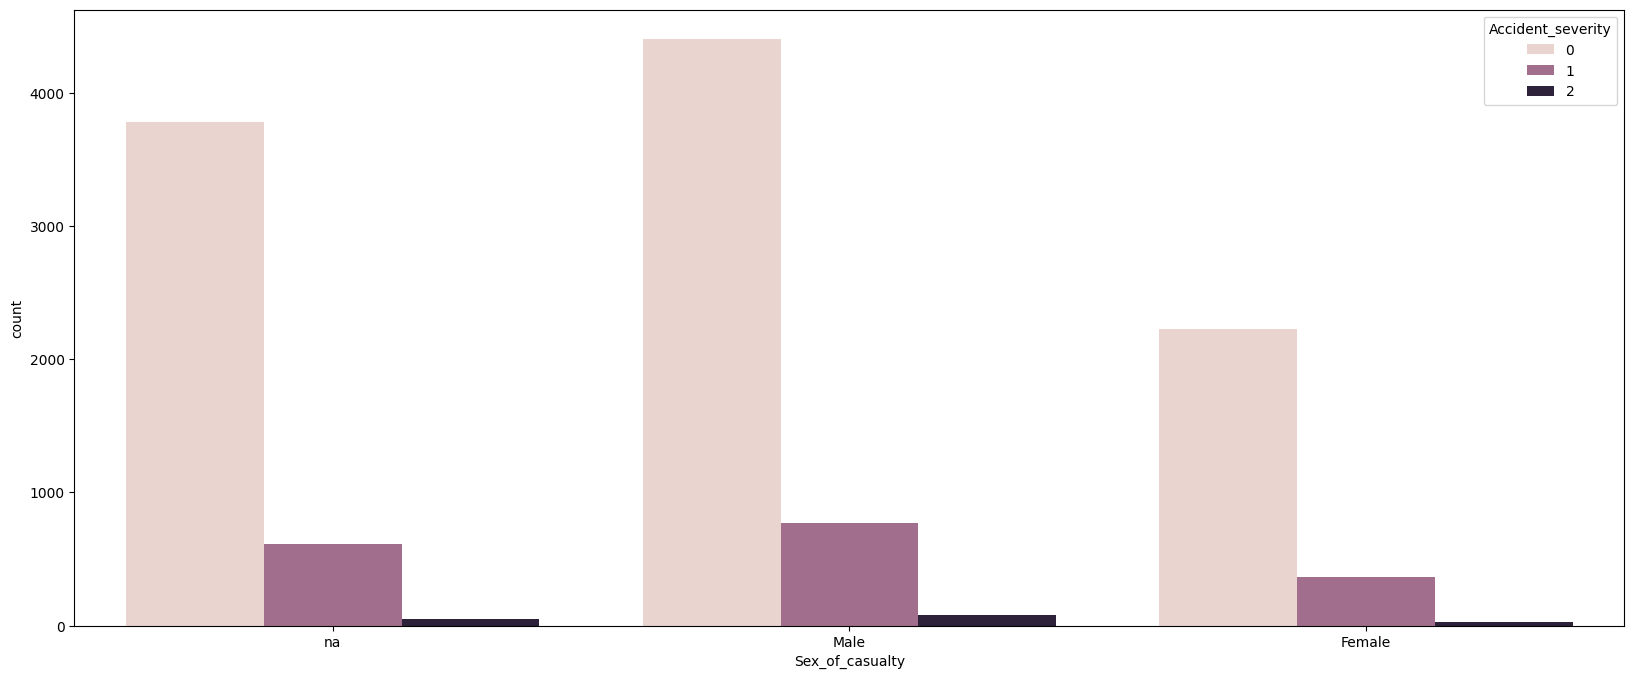

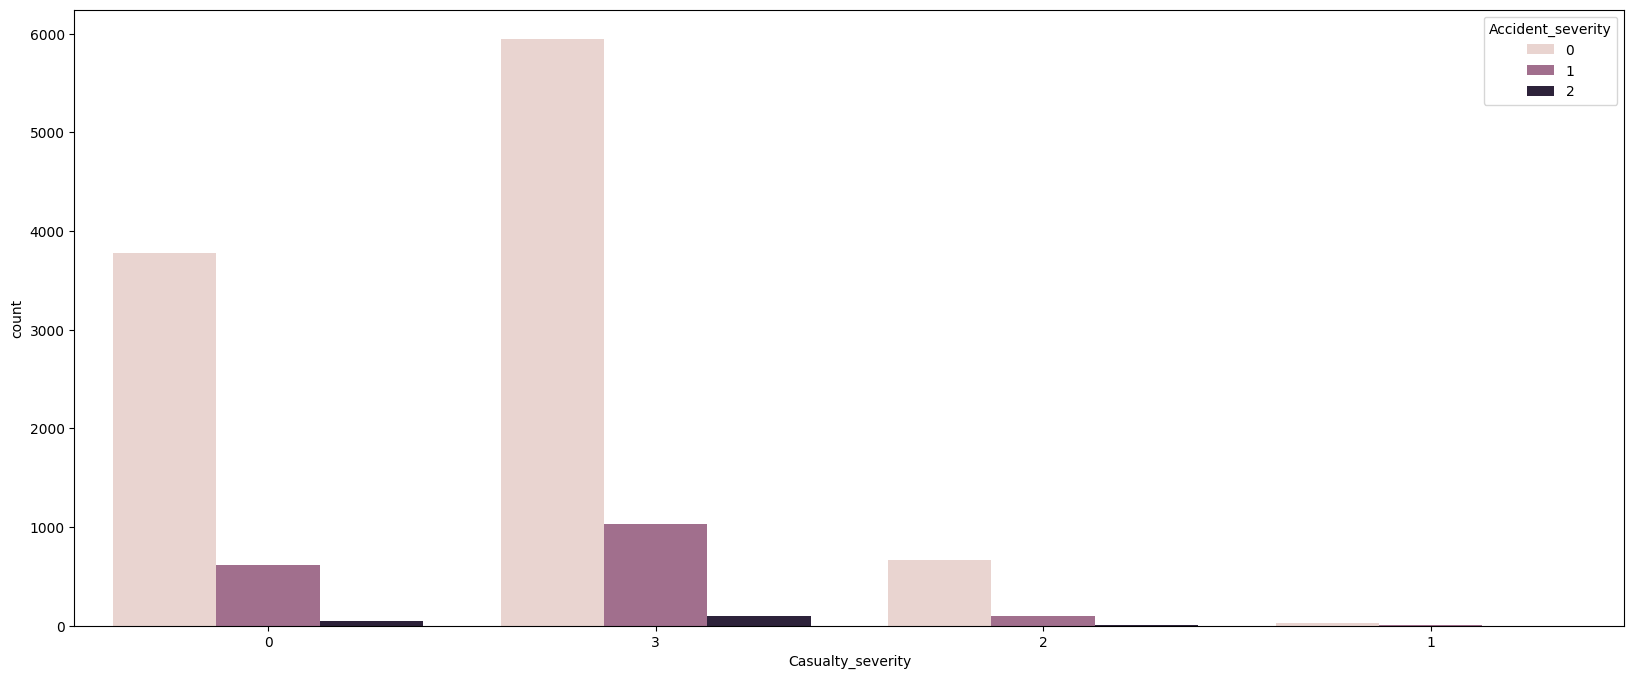

In [ ]:
for i in df:
    if df[i].dtype=='object':
      if len(df[i].value_counts())<5:
          plt.figure(figsize=(20,8))
          sns.countplot(x=df[i],hue=df['Accident_severity'])
          plt.show()

In [ ]:
for i in df:
    if df[i].dtype=='object':
          count_data = df.groupby([i, 'Accident_severity']).size().unstack()
          print(count_data)
          print('-------')

Accident_severity     0    1   2
Time                            
0:01:00             7.0  2.0 NaN
0:02:00             2.0  NaN NaN
0:03:00             2.0  NaN NaN
0:04:00             NaN  1.0 NaN
0:06:00             2.0  NaN NaN
...                 ...  ...  ..
9:55:00            18.0  2.0 NaN
9:56:00             2.0  NaN NaN
9:57:00            11.0  1.0 NaN
9:58:00             1.0  NaN NaN
9:59:00             2.0  NaN NaN

[1074 rows x 3 columns]
-------
Accident_severity     0     1   2
Day_of_week                      
WeekDays           7789  1308  86
Weekend            2626   435  72
-------
Accident_severity      0    1   2
Age_band_of_driver               
18-30               3605  604  62
31-50               3492  541  54
Over 51             1304  257  24
Under 18             644  169  12
Unknown             1370  172   6
-------
Accident_severity     0     1    2
Sex_of_driver                     
Female              592   104    5
Male               9664  1621  152
Unknown 

In [ ]:
df['Accident_severity']=df['Accident_severity'].replace(['Fatal injury','Serious Injury','Slight Injury'],[2,1,0])

<Axes: xlabel='Hour', ylabel='count'>

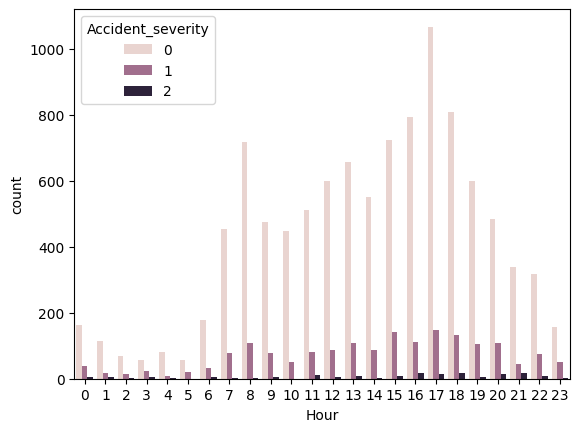

In [ ]:
sns.countplot(x=df['Hour'],hue=df['Accident_severity'])

In [ ]:
count_data = df.groupby(['Hour', 'Accident_severity']).size().unstack()
print(count_data)

Accident_severity       0      1     2
Hour                                  
0                   163.0   38.0   5.0
1                   113.0   17.0   4.0
2                    70.0   13.0   1.0
3                    56.0   22.0   6.0
4                    81.0    9.0   1.0
5                    56.0   20.0   NaN
6                   178.0   32.0   4.0
7                   454.0   77.0   1.0
8                   718.0  108.0   2.0
9                   475.0   78.0   6.0
10                  448.0   52.0   NaN
11                  511.0   80.0  12.0
12                  598.0   88.0   5.0
13                  657.0  108.0   7.0
14                  550.0   86.0   3.0
15                  724.0  142.0   8.0
16                  794.0  111.0  16.0
17                 1066.0  149.0  13.0
18                  808.0  132.0  16.0
19                  599.0  104.0   5.0
20                  483.0  107.0  14.0
21                  339.0   45.0  17.0
22                  318.0   75.0   9.0
23                  156.0

In [ ]:
df['Casualty_severity']=df['Casualty_severity'].replace('na',0)

In [ ]:
df['Casualty_severity']=df['Casualty_severity'].astype(int)

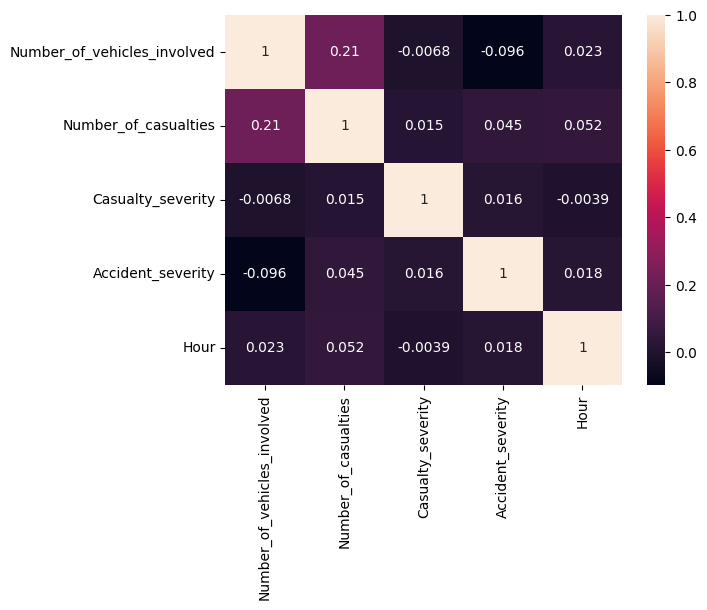

In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot = True);

In [ ]:
df['Accident_severity'].value_counts()

,count
Accident_severity,
0,10415
1,1743
2,158


**Dropping Column**

In our analysis so far, we have dropped columns that are irrelevant and have no relationship with the outcome variable. This helps streamline the dataset, reducing noise and improving model performance by focusing only on features that contribute meaningful information for prediction.

In [ ]:
df.drop(columns=['Defect_of_vehicle','Service_year_of_vehicle','Owner_of_vehicle','Lanes_or_Medians','Time','Work_of_casuality','Casualty_severity','Educational_level','Vehicle_driver_relation','Sex_of_driver','Sex_of_casualty'],inplace=True)

**Handling the missing values**


In handling missing values, we replaced the missing entries in specific columns with the most frequent value (mode). We selected columns where increasing the majority class does not significantly affect the outcome. This approach ensures that filling in missing values does not skew the distribution in a way that could introduce bias or compromise the model's accuracy. Additionally, for rows with null values that could not be appropriately filled, we opted to drop these rows to maintain data quality and consistency. This combined approach of filling and dropping minimizes potential data distortions while preserving the integrity of the analysis.

In [ ]:
df['Fitness_of_casuality'].fillna(df['Fitness_of_casuality'].mode()[0], inplace=True)

<ipython-input-732-1f4e8f423344>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fitness_of_casuality'].fillna(df['Fitness_of_casuality'].mode()[0], inplace=True)


In [ ]:
df['Driving_experience'].fillna(df['Driving_experience'].mode()[0], inplace=True)

<ipython-input-733-9cd0b8b403dc>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Driving_experience'].fillna(df['Driving_experience'].mode()[0], inplace=True)


In [ ]:
df['Type_of_vehicle'].fillna(df['Type_of_vehicle'].mode()[0], inplace=True)

<ipython-input-734-5a875211bfff>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type_of_vehicle'].fillna(df['Type_of_vehicle'].mode()[0], inplace=True)


In [ ]:
df['Types_of_Junction'].fillna(df['Types_of_Junction'].mode()[0], inplace=True)

<ipython-input-735-53b52975fba4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Types_of_Junction'].fillna(df['Types_of_Junction'].mode()[0], inplace=True)


In [ ]:
df.isna().sum()

,0
Day_of_week,0
Age_band_of_driver,0
Driving_experience,0
Type_of_vehicle,0
Area_accident_occured,239
Road_allignment,142
Types_of_Junction,0
Road_surface_type,172
Road_surface_conditions,0
Light_conditions,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isna().sum()

,0
Day_of_week,0
Age_band_of_driver,0
Driving_experience,0
Type_of_vehicle,0
Area_accident_occured,0
Road_allignment,0
Types_of_Junction,0
Road_surface_type,0
Road_surface_conditions,0
Light_conditions,0


# **MODEL BUILDING**
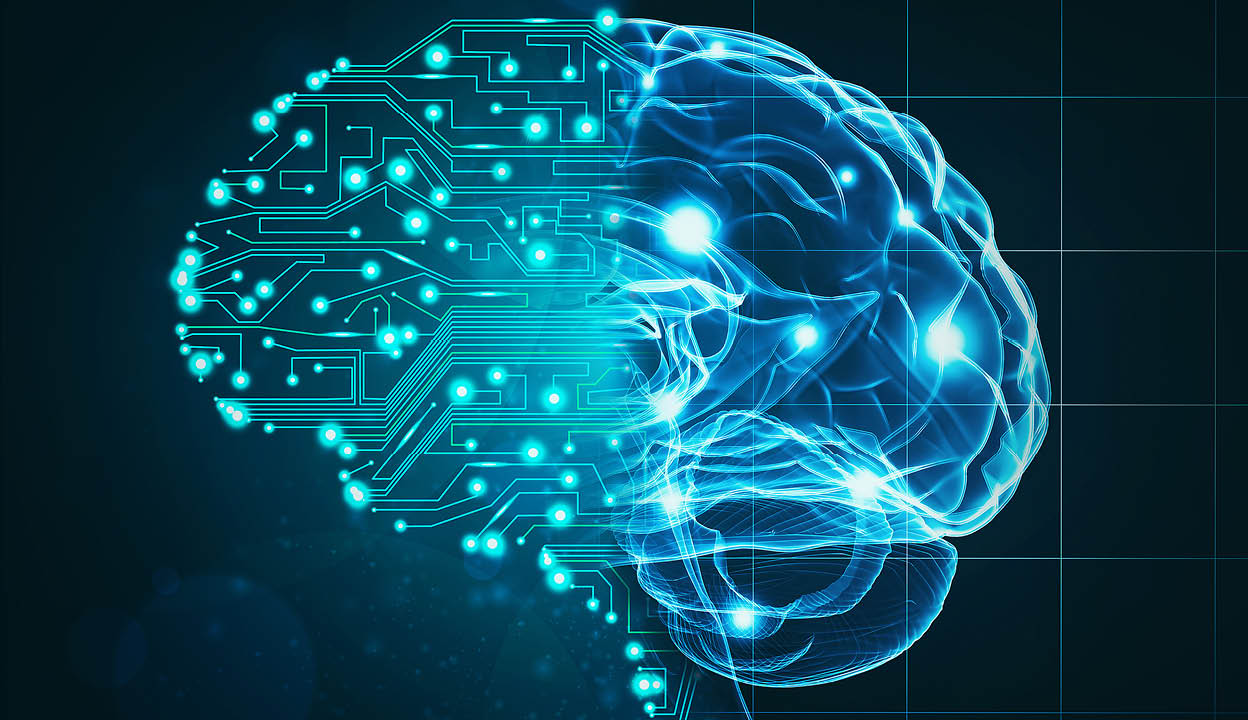

**Encoding**

In [ ]:
oh=[]
for i in df:
  if df[i].dtype=='object':
    if len(df[i].value_counts())>=2:
      oh.append(i)
print(oh)

['Day_of_week', 'Age_band_of_driver', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Age_band_of_casualty', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident']


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
onehot = OneHotEncoder(sparse_output=False,drop = 'first')
res = onehot.fit_transform(df[['Day_of_week', 'Age_band_of_driver', 'Driving_experience', 'Type_of_vehicle','Area_accident_occured','Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Age_band_of_casualty', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident']])
res = pd.DataFrame(res,dtype=int)
res

,0,1,2,3,4,5,6,7,8,9,...,116,117,118,119,120,121,122,123,124,125
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11339,0,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
11340,1,0,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
11341,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11342,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.drop(columns=['Day_of_week', 'Age_band_of_driver', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Age_band_of_casualty', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident'],inplace=True)

In [ ]:
res.columns = res.columns.astype(str)

In [ ]:
df.reset_index(drop=True,inplace=True)

In [ ]:
df = df.join(res)

In [ ]:
df

,Number_of_vehicles_involved,Number_of_casualties,Accident_severity,Hour,0,1,2,3,4,5,...,116,117,118,119,120,121,122,123,124,125
0,2,2,0,17,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,2,0,17,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,2,2,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2,2,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,2,1,0,17,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11339,2,1,0,16,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
11340,2,1,0,18,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
11341,1,1,1,13,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11342,2,1,0,13,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
x=df.drop(columns='Accident_severity')
y=df.Accident_severity

**Sampling**

In [ ]:
from imblearn.over_sampling import SMOTE
sampler=SMOTE()
x,y=sampler.fit_resample(x,y)

**Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split , cross_val_score , RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler , LabelEncoder , OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB , MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

**Scaling**

In [ ]:
minmax=MinMaxScaler()
x_train_scaled=minmax.fit_transform(x_train)
x_test_scaled=minmax.transform(x_test)

**Model Selection**

In [ ]:
models  = [KNeighborsClassifier(),SVC(),GaussianNB(),DecisionTreeClassifier(),RandomForestClassifier(),GradientBoostingClassifier(),XGBClassifier()]
for i in models:
  i.fit(x_train_scaled,y_train)
  y_pred=i.predict(x_test_scaled)
  print(i)
  print(classification_report(y_test,y_pred))
  print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.97      0.35      0.51      2905
           1       0.61      0.89      0.72      2870
           2       0.84      1.00      0.91      2876

    accuracy                           0.74      8651
   macro avg       0.80      0.74      0.71      8651
weighted avg       0.80      0.74      0.71      8651

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
SVC()
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2905
           1       0.90      0.73      0.81      2870
           2       0.89      0.95      0.92      2876

    accuracy                           0.88      8651
   macro avg       0.88      0.88      0.88      8651
weighted avg       0.88      0.88      0.88      8651

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
GaussianNB()
              precision    recall  f1-score   support

           0       0.84      0.23      0.36

**Cross-validation**

In [ ]:
from sklearn.model_selection import cross_val_score
print(cross_val_score(RandomForestClassifier(),minmax.transform(x),y,cv=5,scoring='accuracy').mean())

0.9258614884486726


**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
parameters={'n_estimators':[i for i in range(10,600,10)],'criterion':['gini','entropy'],
            'max_depth':[i for i in range(10,150,10)],
            'min_samples_split':list(range(10,50,5))}
rs_cv=RandomizedSearchCV(RandomForestClassifier(),parameters,cv=5,n_iter=6)
rs_cv.fit(x_train_scaled,y_train)
print(rs_cv.best_score_)
print(rs_cv.best_params_)

0.9154817934109488
{'n_estimators': 170, 'min_samples_split': 15, 'max_depth': 40, 'criterion': 'entropy'}


In [ ]:
rs_cv.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=40, min_samples_split=15,
                       n_estimators=170)

**Model Deployment**

In [ ]:
final_model=rs_cv.best_estimator_

**Final testing**

In [ ]:
y_pred=final_model.predict(x_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      2905
           1       0.91      0.87      0.89      2870
           2       0.99      0.99      0.99      2876

    accuracy                           0.92      8651
   macro avg       0.93      0.92      0.92      8651
weighted avg       0.93      0.92      0.92      8651

